# Machine Learning for CICY 4-Folds

H. Erbin, R. Finotello

Following the analysis in [arXiv:2007.13379](https://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](https://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds.
The idea is to see whether the Inception network can also be applied in higher dimensions.

## Inception Network

In this notebook we build a model of the Inception network and apply it to the configuration matrix of CICY 4-folds.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import json
import joblib
from joblib import Parallel, delayed
from nn_tools.utils.plotutils import *
from nn_tools.utils.datacreate import *
from nn_tools.utils.dirstruct import *
from nn_tools.nn_models.models import *
from nn_tools.nn_models.callbacks import *
from IPython.display import Image

In [2]:
random_state = 123
np.random.seed(random_state)
tf.random.set_seed(random_state)

## Parameters

Throughout the notebook we will use certain parameters to be able to automate the procedure:

In [3]:
parameters = {'aux_output': False,
              'aux_suff':   'aux',
              'outliers':   (0.005, 0.995),
              'rescale':    False
             }

## Create a Saving Directory

Each model will be assigned to a different directory based on the time of running.

In [4]:
img_dir, mod_dir = dir_struct(prefix='inception', dirs=['img', 'models'])

Current working directories:

  ./img/inception_20201211_193827
  ./models/inception_20201211_193827


In [5]:
with open(os.path.join(mod_dir, 'parameters.json'), 'w') as f:
    json.dump(parameters, f)

## Load the Dataset

We then download the JSON file containing the configuration matrix and the Hodge numbers of the CICY.

In [6]:
df, (n_rows, n_cols) = load_json('https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_matrix.json.gz', orient='index')

Size of the dataset: 905684 rows, 5 columns.


We then split it into train, validation and test sets:

In [7]:
df_splits = {'train_split': 0.95, 'val_split': 0.5}
with open(os.path.join(mod_dir, 'train_ratio.json'), 'w') as f:
    json.dump(df_splits, f)

(df_train, df_val, df_test), (n_train, n_val, n_test) = train_test(df, df_splits)

assert n_train + n_val + n_test == n_rows, 'Dimensions do not add up to the original size!'

In [8]:
del df

## Outliers in the Training Set

We then study the outliers in the training set:

In [9]:
low, high = parameters['outliers']
outliers  = df_train.quantile([low, high])

outliers

In [9]:
if 0.0 < low < high < 1.0:
    df_train, n_train_pruned = remove_outliers(df_train, outliers=outliers)

Samples removed: 12977 (1.51% of the training set)


## Rescale the Matrices

We then rescale the matrices in the sets to improve the deep learning results:

In [10]:
rescaling = {'min': df_train['matrix'].apply(lambda x: np.min(x)).min(),
             'max': df_train['matrix'].apply(lambda x: np.max(x)).max()
            } if parameters['rescale'] else None

## Feature and Label Creation

We then create the features and the labels.

In [11]:
reshape = np.shape(df_train['matrix'].iloc[0]) + (1,)

In [12]:
X_train, X_val, X_test = Parallel(n_jobs=-1)\
                         (delayed(lambda d: create_features(d['matrix'], rescaling=rescaling, reshape=reshape))(df) \
                          for df in [df_train, df_val, df_test]
                         )

In [13]:
y_train, y_val, y_test = Parallel(n_jobs=-1)\
                         (delayed(lambda d: create_labels(d[['h11', 'h21', 'h31', 'h22']]))(df) \
                          for df in [df_train, df_val, df_test]
                         )

In [14]:
if parameters['aux_output']:
    y_aux_train, y_aux_val, y_aux_test = Parallel(n_jobs=-1)\
                                         (delayed(lambda d: create_labels(d[['h11', 'h21', 'h31', 'h22']], suff=parameters['aux_suff']))(df) \
                                          for df in [df_train, df_val, df_test]
                                         )
    y_train.update(y_aux_train)
    y_val.update(y_aux_val)
    y_test.update(y_aux_test)

In [15]:
del df_train, df_val, df_test

## Save Training Data to File

We finally save the training data to file in order to have a different notebook compute the predictions.

In [16]:
joblib.dump(X_train, os.path.join(mod_dir, 'X_train.joblib'))
joblib.dump(X_val, os.path.join(mod_dir, 'X_val.joblib'))
joblib.dump(X_test, os.path.join(mod_dir, 'X_test.joblib'))
    
joblib.dump(y_train, os.path.join(mod_dir, 'y_train.joblib'))
joblib.dump(y_val, os.path.join(mod_dir, 'y_val.joblib'))
joblib.dump(y_test, os.path.join(mod_dir, 'y_test.joblib'))

['./models/inception_20201211_193827/y_test.joblib']

## Inception Model

We then start to build the Inception model to be trained on the configuration matrices.

### Build the Model

In [17]:
model_data = {'input_shape':         reshape,
              'name':                'matrix',
              'learning_rate':       1.0e-3,
              'output_names':        ['h11', 'h21', 'h31', 'h22'],
              'conv_1b1':            False,
              'conv_layers':         [128, 64, 32],
              'conv_alpha':          0.0,
              'conv_class':          None,
              'conv_single':         False,
              'conv_red':            0,
              'feat_map':            32,
              'recurrent':           False,
              'fc_layers':           [],
              'fc_alpha':            0.0,
              'dropout':             0.1,
              'full_dropout':        0.01,
              'batchnorm':           0.99,
              'last_relu':           True,
              'loss_weights':        [0.15, 0.15, 0.30, 0.40],
              'l1_reg':              1.0e-3,
              'l2_reg':              1.0e-3,
              'auxiliary_fc':        [4] if parameters['aux_output'] else None,
              'auxiliary_alpha':     0.0,
              'auxiliary_last_relu': True,
              'auxiliary_suff':      parameters['aux_suff'],
              'output_layers':       True,
              'random_state':        random_state
             }

with open(os.path.join(mod_dir, 'model_data.json'), 'w') as f:
    json.dump(model_data, f)

In [18]:
inception = nn_inception(**model_data)
inception.summary()

Model: "matrix"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
matrix (InputLayer)             [(None, 16, 20, 1)]  0                                            
__________________________________________________________________________________________________
matrix_convAa_0 (Conv2D)        (None, 16, 20, 128)  2176        matrix[0][0]                     
__________________________________________________________________________________________________
matrix_convAb_0 (Conv2D)        (None, 16, 20, 128)  2688        matrix[0][0]                     
__________________________________________________________________________________________________
matrix_actAa_0 (LeakyReLU)      (None, 16, 20, 128)  0           matrix_convAa_0[0][0]            
_____________________________________________________________________________________________

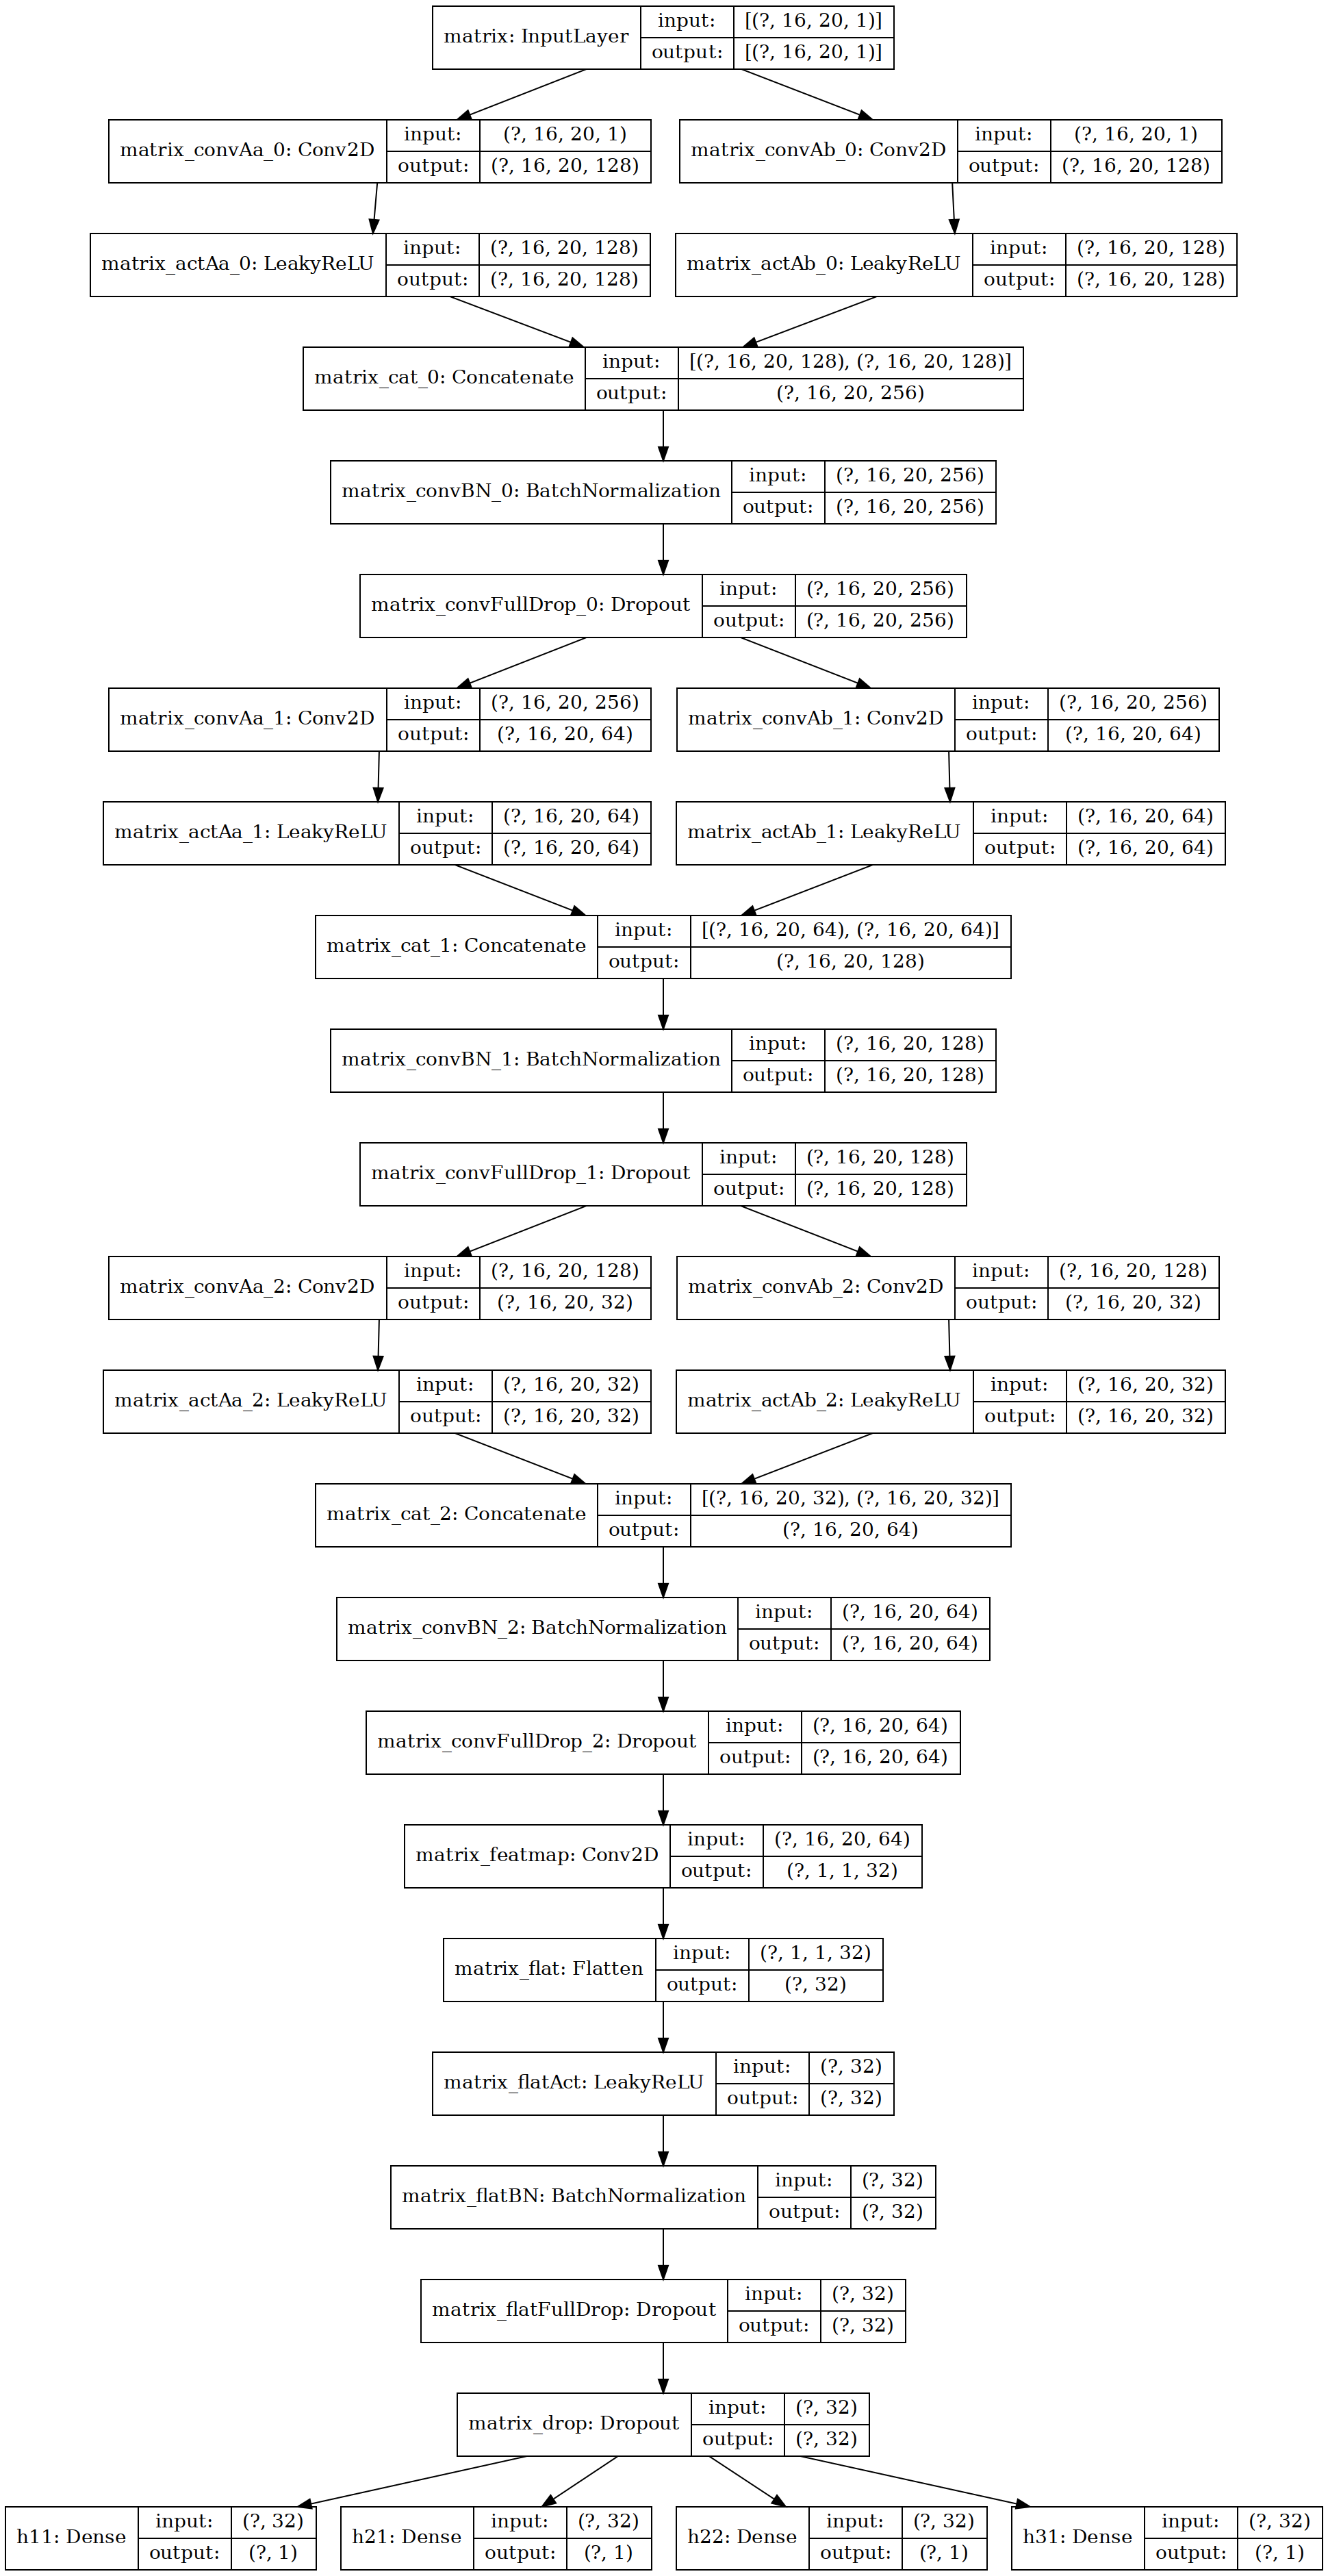

In [19]:
inception_graph = keras.utils.model_to_dot(inception, show_shapes=True, dpi=144)
inception_graph.write_pdf(os.path.join(img_dir, 'inception.pdf'))
Image(inception_graph.create_png(), width=480)

### Train the Model

In [20]:
fit_data = {'epochs':        10,
            'batch_size':    32,
            'reduce_lr':     5,
            'stat_interval': 1
           }

with open(os.path.join(mod_dir, 'fit_data.json'), 'w') as f:
    json.dump(fit_data, f)

In [21]:
callbacks = model_checkpoints(list(inception.output.keys()),
                              root=mod_dir,
                              reduce_lr=0.1,
                              lr_patience=fit_data['reduce_lr'],
                              summary=fit_data['stat_interval']
                             )

inception_hst = inception.fit(x=X_train,
                              y=y_train,
                              batch_size=fit_data['batch_size'],
                              epochs=fit_data['epochs'],
                              verbose=0,
                              callbacks=callbacks,
                              validation_data=(X_val, y_val)
                             )

Training has started. Callouts will be printed every epoch.

Training epoch 1. Started on 11/12/2020 at 19:40:19.

    Average epoch training time: 00 hours, 05 minutes, 38 seconds

    loss = 1274.020874
    h11_loss = 7.617410
    h21_loss = 3.269430
    h22_loss = 3043.819092
    h31_loss = 74.968315
    h11_mean_squared_error = 7.617410
    h11_mean_absolute_error = 1.828799
    h21_mean_squared_error = 3.269430
    h21_mean_absolute_error = 0.981239
    h22_mean_squared_error = 3043.819092
    h22_mean_absolute_error = 28.988499
    h31_mean_squared_error = 74.968315
    h31_mean_absolute_error = 5.269630
    val_loss = 375.323212
    val_h11_loss = 4.888219
    val_h21_loss = 3.071522
    val_h22_loss = 853.986145
    val_h31_loss = 31.231571
    val_h11_mean_squared_error = 4.888219
    val_h11_mean_absolute_error = 1.183340
    val_h21_mean_squared_error = 3.071522
    val_h21_mean_absolute_error = 0.873888
    val_h22_mean_squared_error = 853.986145
    val_h22_mean_absolute_e

## Visualisation of the Training Data

We plot the metrics and the loss of the training for reference.

In [22]:
inception_hst = pd.DataFrame(inception_hst.history)
inception_hst.to_json(os.path.join(mod_dir, 'history.json'), orient='index')

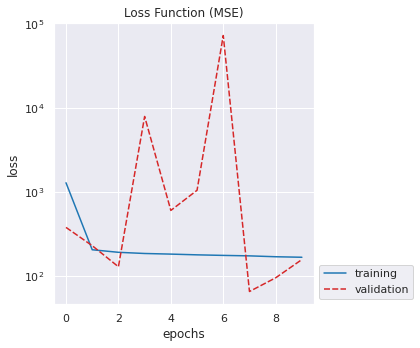

In [23]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.lineplot(data=inception_hst[['loss', 'val_loss']],
             palette=['tab:blue', 'tab:red'],
             ax=ax
            )
ax.set(title='Loss Function (MSE)',
       xlabel='epochs',
       ylabel='loss',
       yscale='log'
      )
ax.legend(['training', 'validation'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

savefig('inception_loss', fig, root=img_dir, show=True)

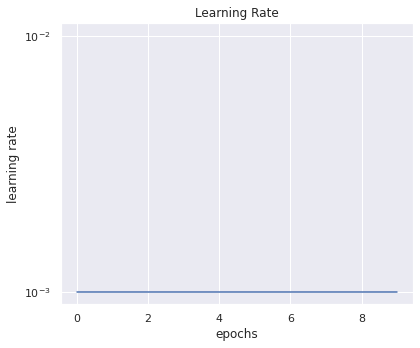

In [24]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.lineplot(data=inception_hst['lr'],
             ax=ax
            )
ax.set(title='Learning Rate',
       xlabel='epochs',
       ylabel='learning rate',
       yscale='log'
      )

savefig('inception_lr', fig, root=img_dir, show=True)